#**Домашнее задание №1**
##**Выполнила:** Шумилова Мария Константиновна 409920 U3310
##**Проверила:** Желтова Кристина Анатольевна

# **Бизнес-постановка задачи**

Во многих компаниях важно заранее понимать, какие сотрудники находятся в зоне риска увольнения. Это нужно для того, чтобы HR-отдел мог вовремя заметить потенциальные проблемы, предложить меры удержания, снизить текучесть кадров и сократить затраты на поиск и обучение новых сотрудников.  
В рамках данной работы хочется построить модель, которая по информации о сотруднике будет предсказывать, уволится ли он из компании. Такой инструмент может помочь компании заранее выделять сотрудников с высоким риском attrition и принимать управленческие решения на основе данных.

# **Постановка ML-задачи**

В данной работе задача формулируется как **бинарная классификация**.  
Целевая переменная: `Attrition` — уволился сотрудник (`Yes`) или нет (`No`).  
Признаки: сведения о сотруднике, такие как возраст, должность, уровень удовлетворенности, доход, стаж, дистанция до работы, сверхурочная работа и другие характеристики.  
Цель модели: по признакам сотрудника предсказать, относится ли он к классу `Attrition = Yes` или `Attrition = No`.

# **Описание набора данных**

Для решения задачи используется датасет **IBM HR Analytics Employee Attrition & Performance** с Kaggle(https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data). Он содержит данные о сотрудниках компании и подходит для задачи предсказания увольнения. В наборе данных 1470 наблюдений и 35 признаков, включая числовые и категориальные переменные.  
Набор данных содержит одну целевую переменную `Attrition` и достаточное количество признаков для построения модели бинарной классификации.  
Преимущества набора данных:  
- данные уже структурированы и пригодны для анализа;  
- есть четко заданная целевая переменная;  
- набор включает как числовые, так и категориальные признаки;  
- размер выборки достаточен для обучения базовых моделей машинного обучения.

# **4. Выбор метрики качества**

В качестве основной метрики качества целесообразно использовать **recall** для класса `Attrition = Yes`.  
Это связано с тем, что в данной задаче особенно важно не пропускать сотрудников, которые действительно могут уволиться: такая ошибка может привести к потере ценного специалиста. Дополнительно можно отслеживать **precision** и **F1-score**, чтобы контролировать баланс между количеством ложных тревог и полнотой обнаружения сотрудников группы риска.

# **5. Разведочный анализ данных (EDA)**

### **5.1 Загрузка библиотек и первичный просмотр данных**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style("whitegrid")

# export KAGGLE_API_TOKEN=KGAT_e32f1e27c3076e0083f2ef1a7904bc58
%pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data")

csv_files = glob.glob("ibm-hr-analytics-attrition-dataset/*.csv")

df = pd.read_csv(csv_files[0])

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bulk2403
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


100%|██████████| 50.1k/50.1k [00:00<00:00, 37.4MB/s]


Найденные CSV-файлы: ['ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv']


На первом этапе загружаем данные и смотрим на первые строки таблицы. Это позволяет понять структуру набора данных, название признаков и формат целевой переменной.

### **5.2 Размер, структура и базовые статистики**

In [ ]:
display(df.head())
print("Размер датасета:", df.shape)
print(df.info())
print(df.isna().sum())
display(df.describe())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Размер датасета: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Вывод по первичному просмотру данных**

После загрузки датасета видно, что он содержит **1470 наблюдений и 35 признаков**, то есть объем данных достаточно большой для выполнения базового анализа и построения модели машинного обучения. В наборе присутствуют как **числовые признаки** (`int64`), так и **категориальные признаки** (`object`), что делает датасет удобным для решения задачи бинарной классификации после предварительной обработки категориальных переменных.

Проверка пропусков показывает, что **во всех столбцах отсутствуют пропущенные значения**. Это является большим плюсом, так как на первом этапе не требуется заполнять пустые данные и можно сразу переходить к анализу распределений, связей между признаками и подготовке данных для обучения модели.

По статистическому описанию видно, что в датасете есть признаки, отражающие **возраст, стаж, доход, удовлетворенность работой, дистанцию до работы, количество компаний в прошлом, уровень вовлеченности и другие характеристики сотрудника**. Такие данные хорошо подходят для анализа факторов, которые могут быть связаны с увольнением сотрудника.

Таким образом, на данном этапе можно сделать вывод, что набор данных является **полным, структурированным и пригодным для дальнейшего EDA и построения модели предсказания attrition**.

### **5.3 Анализ целевой переменной**

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Процентное распределение:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


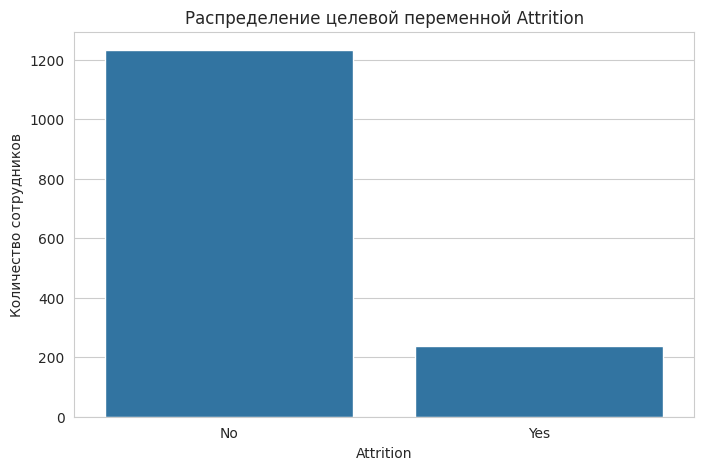

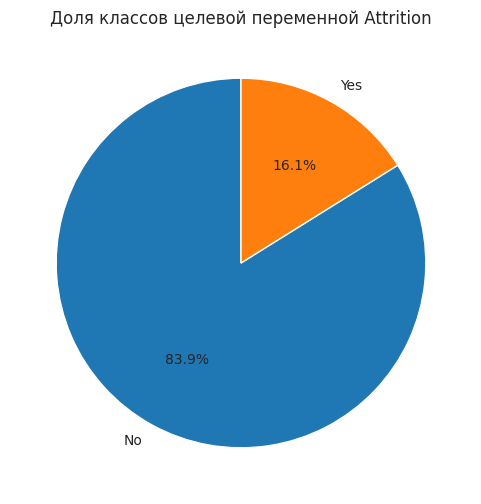

In [ ]:
# Анализ целевой переменной Attrition

# Количество объектов в каждом классе
attrition_counts = df["Attrition"].value_counts()
print(attrition_counts)

# Проценты по каждому классу
attrition_percent = df["Attrition"].value_counts(normalize=True) * 100
print("\nПроцентное распределение:")
print(attrition_percent.round(2))

# Визуализация распределения
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Attrition", order=df["Attrition"].value_counts().index)
plt.title("Распределение целевой переменной Attrition")
plt.xlabel("Attrition")
plt.ylabel("Количество сотрудников")
plt.show()

# Круговая диаграмма
plt.figure(figsize=(6, 6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Доля классов целевой переменной Attrition")
plt.show()

Целевая переменная `Attrition` является бинарной и показывает, уволился сотрудник из компании или нет.  
По результатам анализа распределения классов видно, что в датасете преобладают сотрудники, которые **не уволились** (`No`), а доля сотрудников, которые **уволились** (`Yes`), заметно меньше.

Это означает, что классы в наборе данных **несбалансированы**. Такой дисбаланс важно учитывать при дальнейшем обучении модели, так как простая оценка по accuracy может быть недостаточно информативной. В данной задаче более полезно будет использовать метрики, чувствительные к качеству распознавания редкого класса, например `recall`, `precision` и `F1-score`.

Таким образом, целевая переменная подходит для постановки задачи бинарной классификации, однако при построении модели необходимо учитывать дисбаланс классов и по возможности использовать методы, которые помогут с ним работать.

### **5.4 Распределения признаков**

##### **Числовые**

Выделим числовые признаки

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Числовые признаки:", list(num_cols))

Числовые признаки: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Посмотрим на распределения числовых признаков

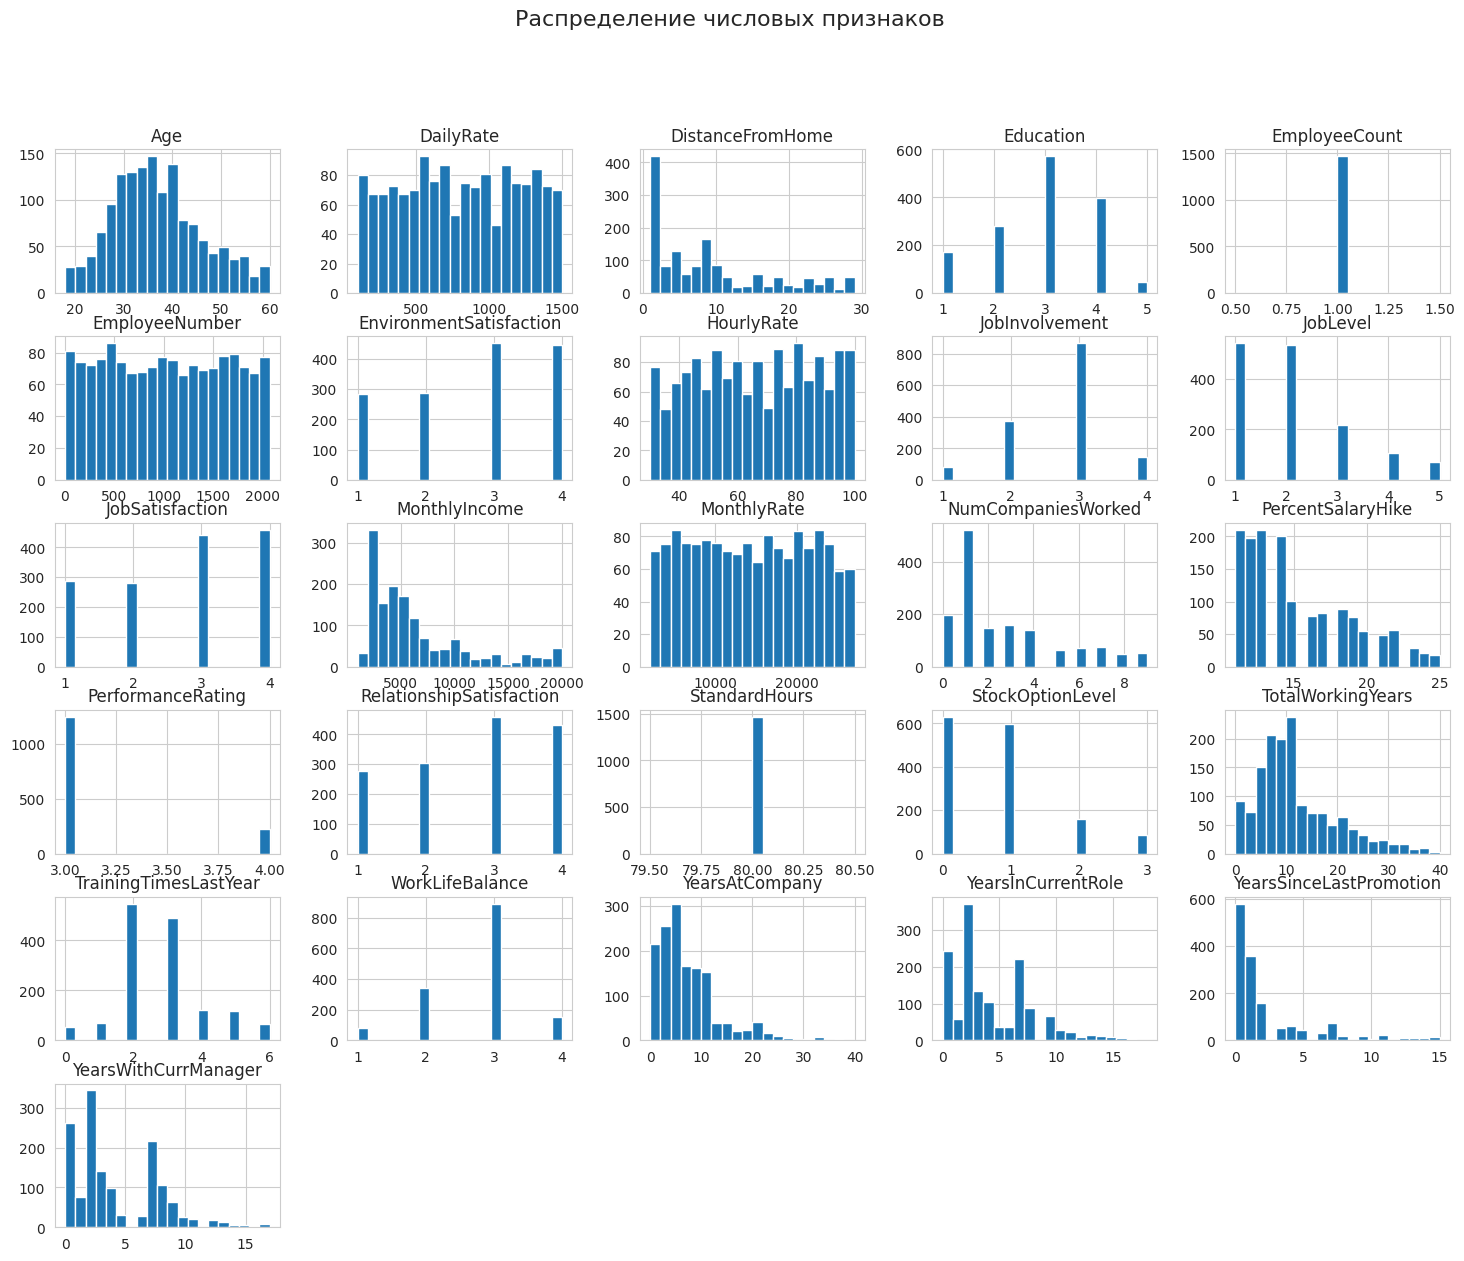

In [8]:
df[num_cols].hist(figsize=(18, 14), bins=20)
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

Посмотрим на распределения признаков в связке с целевой переменной.

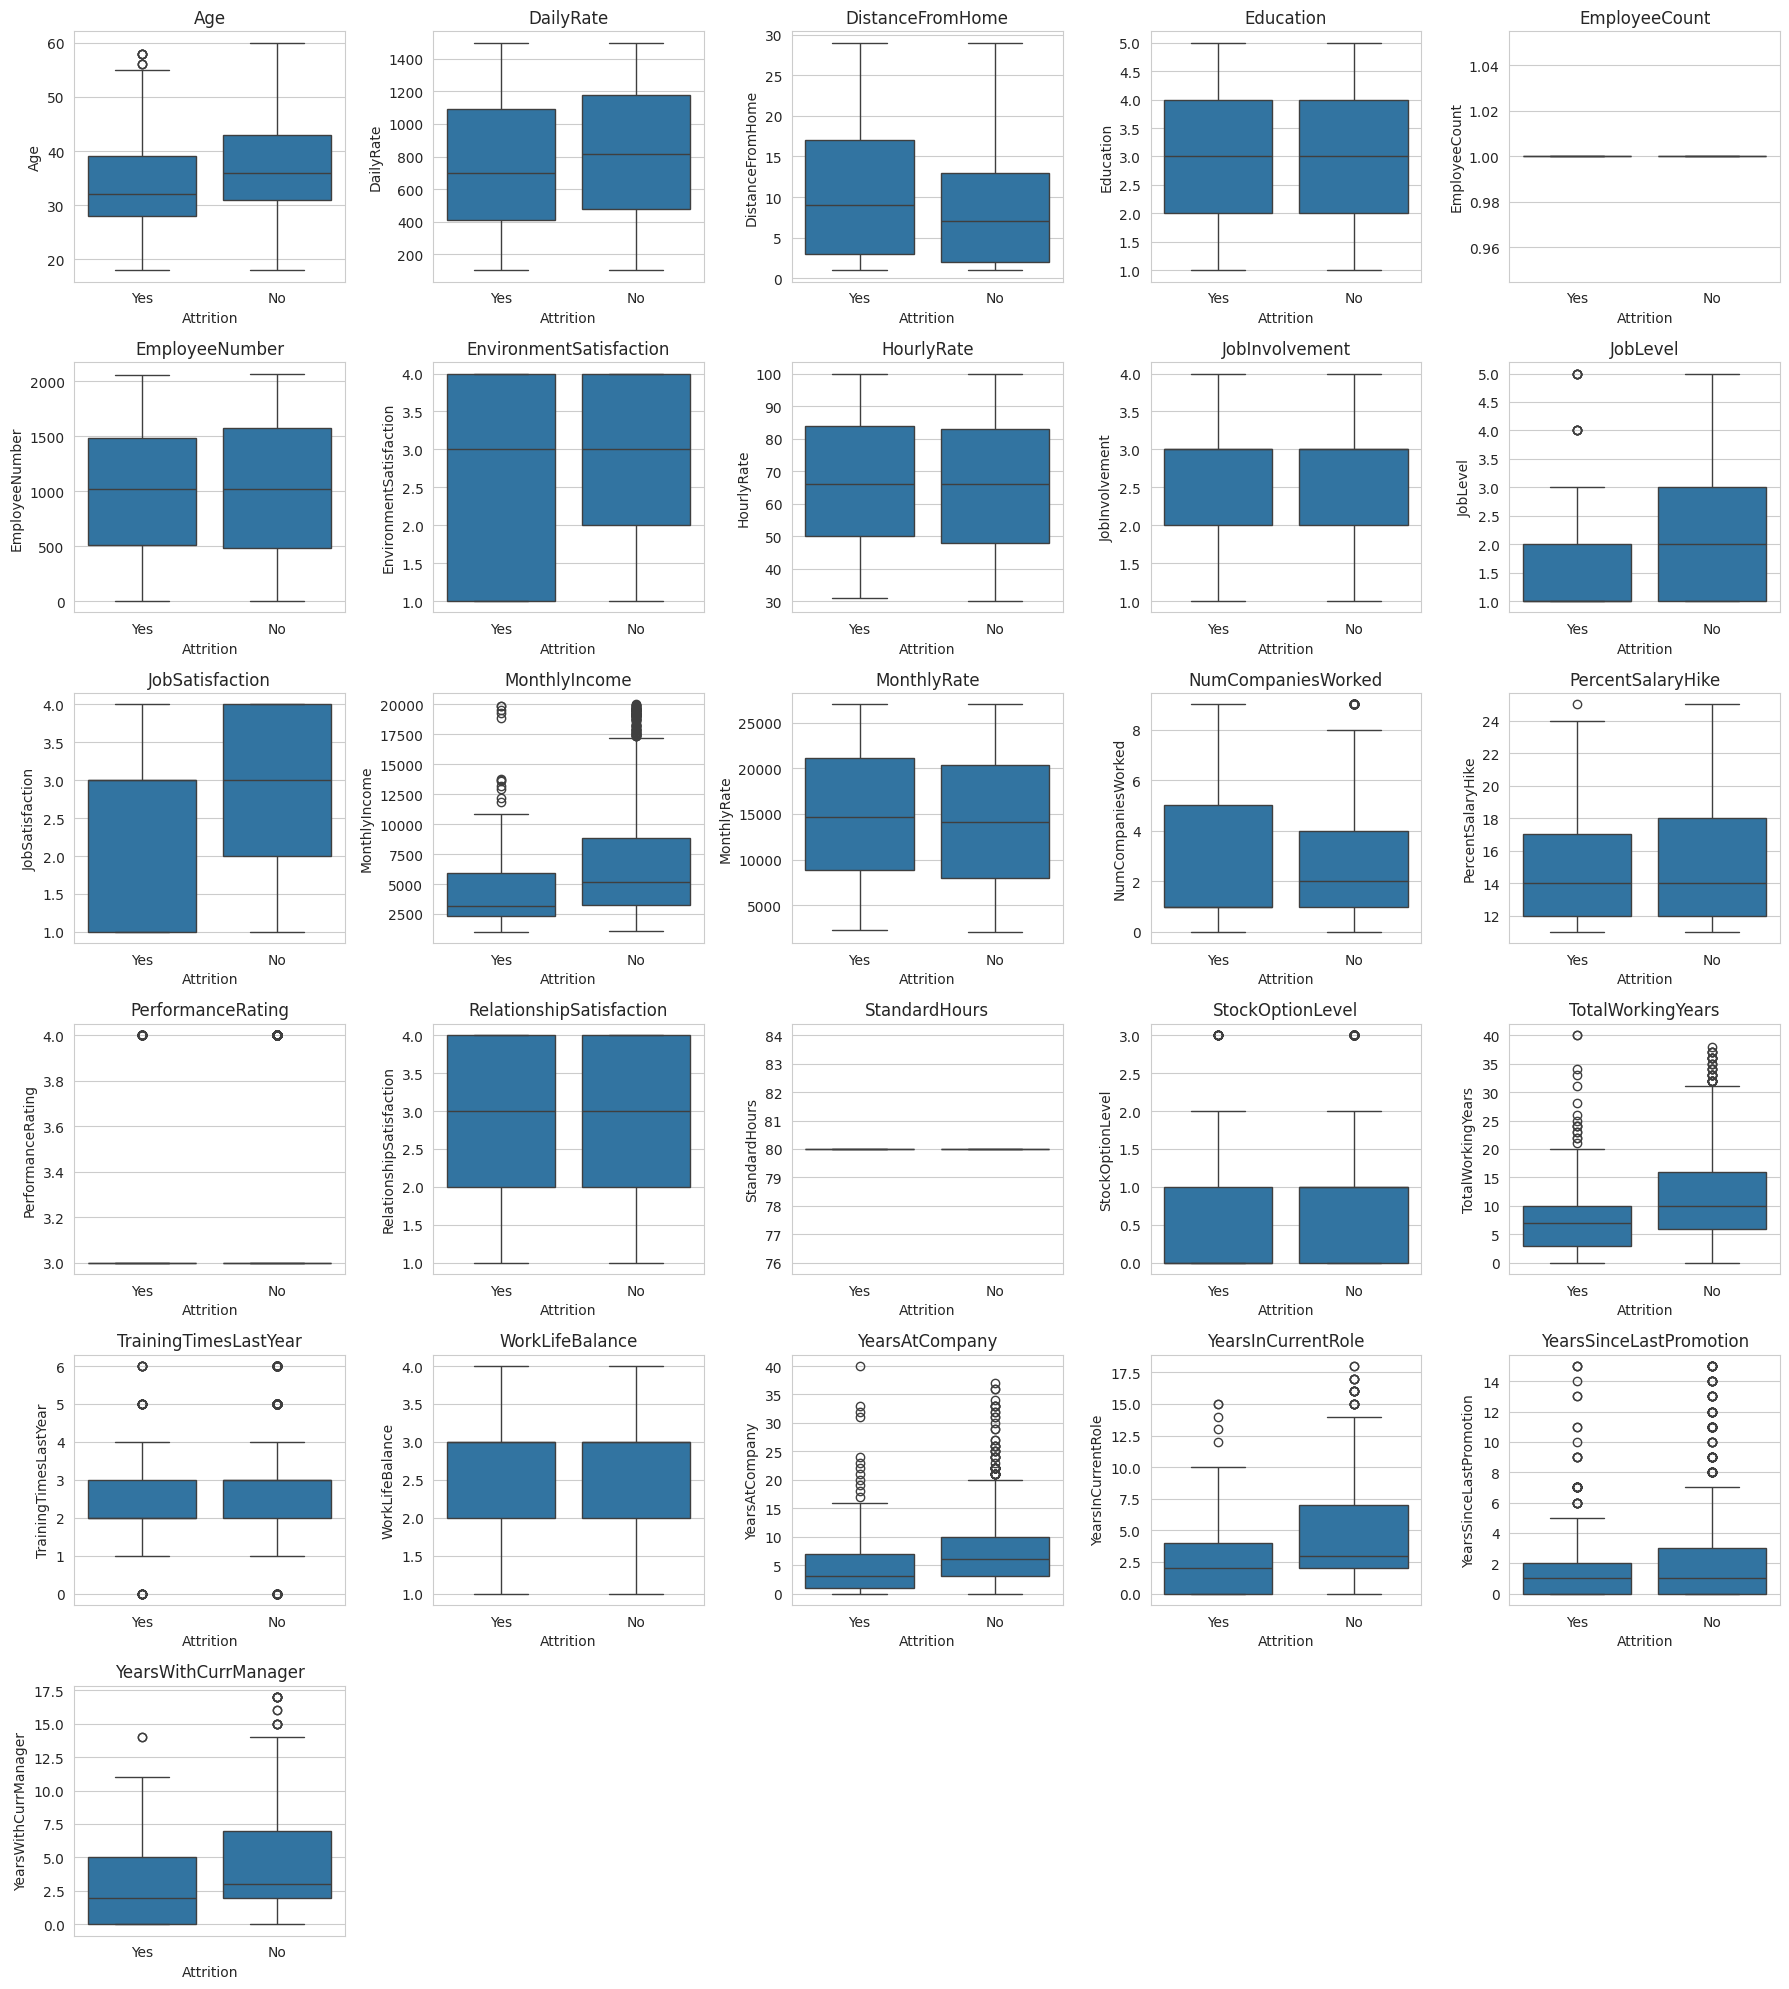

In [12]:
plt.figure(figsize=(18, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 5, i)
    sns.boxplot(data=df, x="Attrition", y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

**Анализ связи числовых признаков с целевой переменной**

На данном этапе был проведён анализ распределения числовых признаков с использованием гистограмм.
По результатам анализа видно, что большинство признаков имеют **неравномерные распределения**, в ряде случаев наблюдается **асимметрия (смещение вправо)**, например у признаков, связанных с доходом (`MonthlyIncome`) и стажем работы (`TotalWorkingYears`). Это может свидетельствовать о наличии небольшого числа сотрудников с очень высокими значениями данных показателей.

Для изучения зависимости между числовыми признаками и целевой переменной `Attrition` были построены boxplot-графики, позволяющие сравнить распределения признаков для сотрудников, которые уволились, и тех, кто остался в компании.

Анализ показал, что по ряду признаков наблюдаются различия между классами:
- сотрудники с меньшим стажем работы (`YearsAtCompany`, `TotalWorkingYears`) чаще увольняются;
- у уволившихся сотрудников в среднем ниже уровень дохода (`MonthlyIncome`);
- признаки, связанные с дистанцией до работы (`DistanceFromHome`), также могут оказывать влияние на вероятность увольнения;
- различия по возрасту (`Age`) также имеют вес. В среднем тенденцию к увольнению имеют сотрудники младше

При этом по некоторым признакам распределения информационно не слишком репрезентативны, что говорит о том, что один признак сам по себе не всегда достаточен для точного предсказания, и для построения модели потребуется учитывать совокупность факторов.

Таким образом, числовые признаки содержат полезную информацию об изменениях целевой переменной, однако к отбору переменных для анализа нужно подходить ответственно.

##### **Категориальные**

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns

print("Категориальные признаки:", list(cat_cols))

Категориальные признаки: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


Посмотрим на распределения переменных

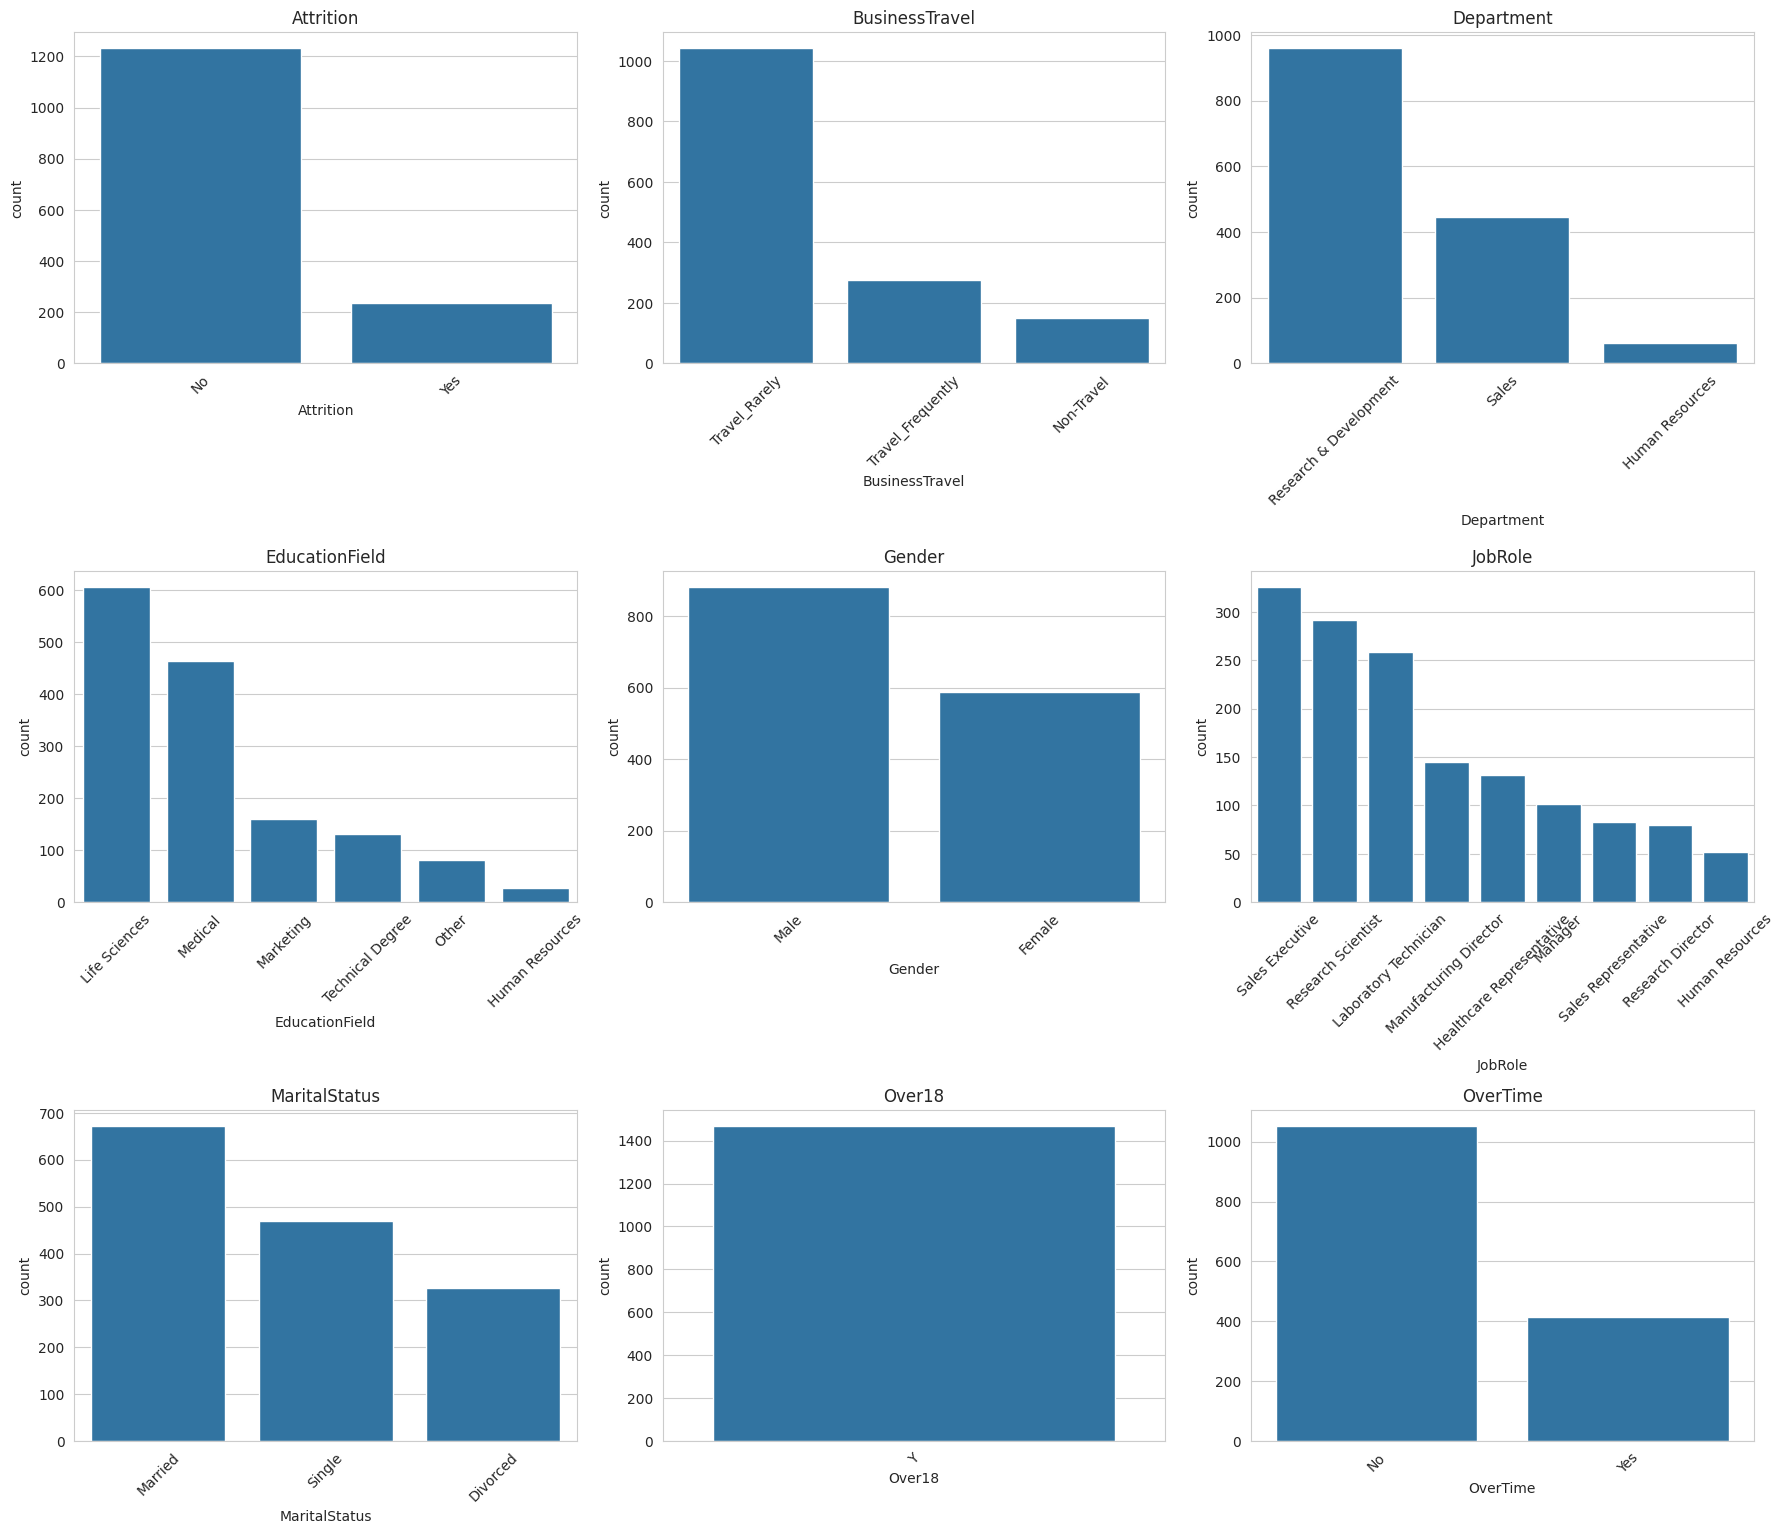

In [10]:
plt.figure(figsize=(18, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Посмотрим на те же распределения в связке с целевой переменной

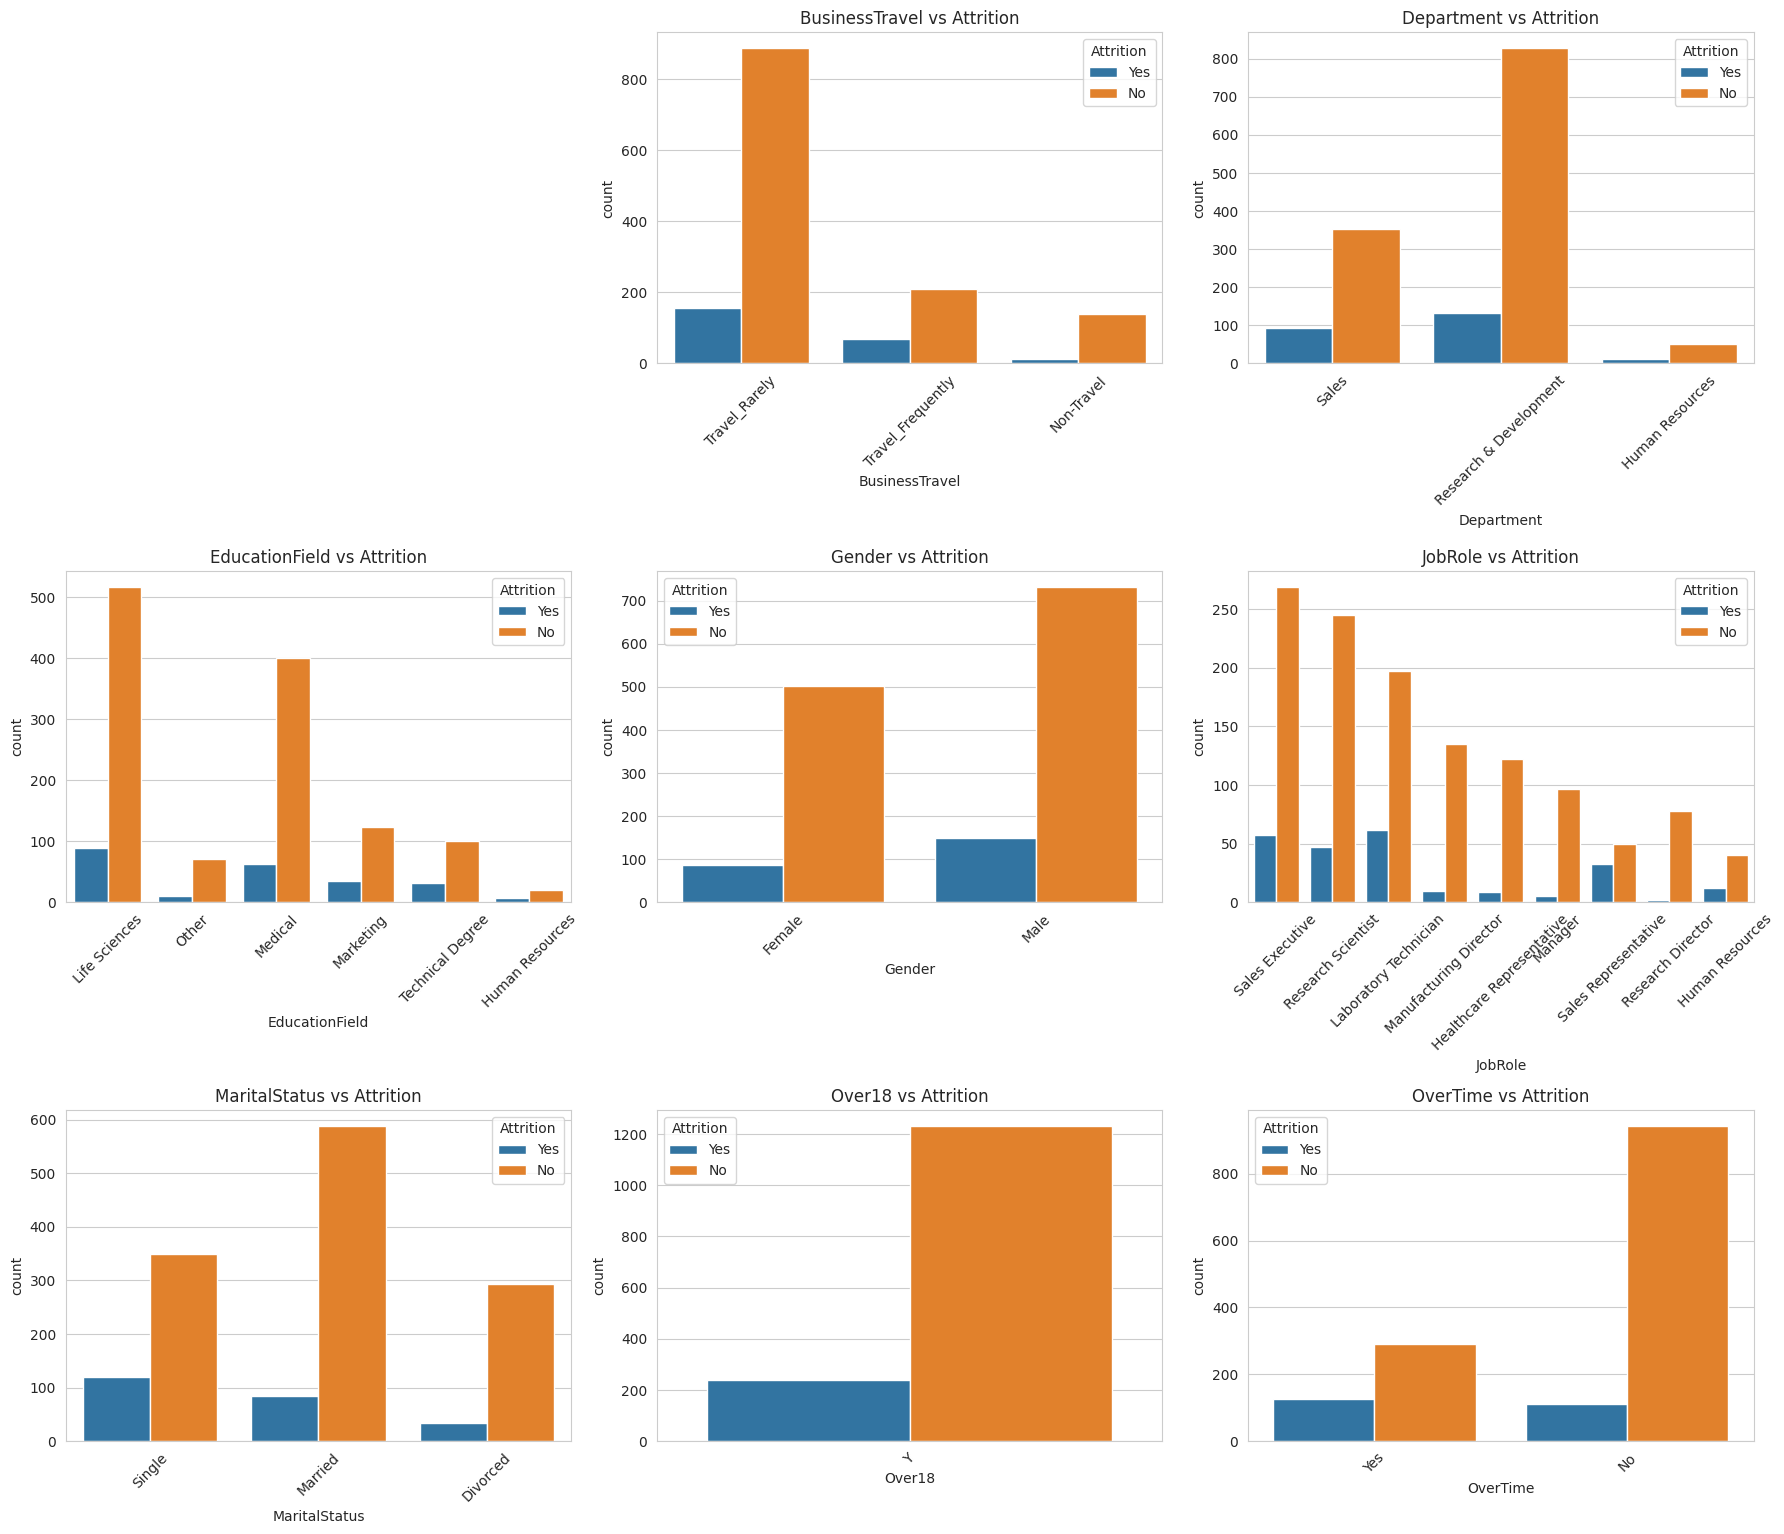

In [13]:
plt.figure(figsize=(18, 20))

for i, col in enumerate(cat_cols, 1):
    if col != "Attrition":
        plt.subplot(4, 3, i)
        sns.countplot(data=df, x=col, hue="Attrition")
        plt.title(f"{col} vs Attrition")
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Анализ категориальных признаков**

На данном этапе были рассмотрены категориальные признаки датасета, а также проанализирована их связь с целевой переменной `Attrition`.

Анализ распределений показал, что в данных присутствуют различные категориальные признаки, такие как отдел (`Department`), должность (`JobRole`), частота командировок (`BusinessTravel`), семейное положение (`MaritalStatus`), наличие сверхурочной работы (`OverTime`) и другие.

При анализе зависимости категориальных признаков от целевой переменной были выявлены следующие закономерности:
- сотрудники, работающие **сверхурочно (`OverTime`)**, чаще увольняются;
- у сотрудников с частыми командировками (`BusinessTravel`) наблюдается более высокая доля увольнений;
- некоторые должности (`JobRole`) и отделы (`Department`) демонстрируют различия в уровне текучести кадров;
- семейное положение (`MaritalStatus`) также может незначительно, но влиять на вероятность увольнения.

Таким образом, категориальные признаки содержат важную информацию для предсказания увольнения сотрудников и должны быть обязательно учтены при построении модели.

### **5.5 Выбросы**

Так как в данном датасете нет пропусков, перейдём сразу к анализу выбросов

In [15]:
# Числовые признаки
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Исключим служебные признаки
exclude_cols = ["EmployeeCount", "StandardHours", "EmployeeNumber"]
num_cols_for_outliers = [col for col in num_cols if col not in exclude_cols]

print("Признаки для анализа выбросов:")
print(num_cols_for_outliers)

Признаки для анализа выбросов:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Количественная оценка выбросов по правилу IQR

In [16]:
outlier_summary = []

for col in num_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_percent = outliers_count / len(df) * 100

    outlier_summary.append({
        "Признак": col,
        "Выбросов": outliers_count,
        "Процент выбросов": round(outliers_percent, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="Процент выбросов", ascending=False)
display(outlier_df)

,Признак,Выбросов,Процент выбросов
17,TrainingTimesLastYear,238,16.19
13,PerformanceRating,226,15.37
9,MonthlyIncome,114,7.76
21,YearsSinceLastPromotion,107,7.28
19,YearsAtCompany,104,7.07
15,StockOptionLevel,85,5.78
16,TotalWorkingYears,63,4.29
11,NumCompaniesWorked,52,3.54
20,YearsInCurrentRole,21,1.43
22,YearsWithCurrManager,14,0.95


**Анализ выбросов**

Для оценки выбросов был проведён количественный анализ числовых признаков с использованием межквартильного размаха (IQR). Результаты показали, что наибольшая доля выбросов наблюдается в признаках `TrainingTimesLastYear` (16.19%) и `PerformanceRating` (15.37%), а также в меньшей степени в `MonthlyIncome`, `YearsSinceLastPromotion` и `YearsAtCompany`.

При этом важно учитывать, что ряд признаков с высокой долей выбросов являются **дискретными или порядковыми** (например, `PerformanceRating`, `TrainingTimesLastYear`, `StockOptionLevel`), поэтому наличие “выбросов” в них связано не с аномалиями, а с особенностями распределения значений. В таких случаях применение стандартного подхода IQR может давать формально высокую долю выбросов, не отражающую реальные ошибки в данных.

Для признаков, имеющих более непрерывную природу (например, `MonthlyIncome`, `TotalWorkingYears`), наличие выбросов может быть обусловлено реальными различиями между сотрудниками, такими как высокий доход или большой стаж работы.

Также стоит отметить, что для значительной части признаков выбросы отсутствуют, что свидетельствует о достаточно стабильной структуре данных.

Таким образом, выявленные выбросы не носят критического характера, и их удаление на данном этапе не является обязательным. В рамках дальнейшего анализа целесообразно сохранить все наблюдения, так как они могут содержать важную информацию для модели.

### **5.6 Матрица корреляций**

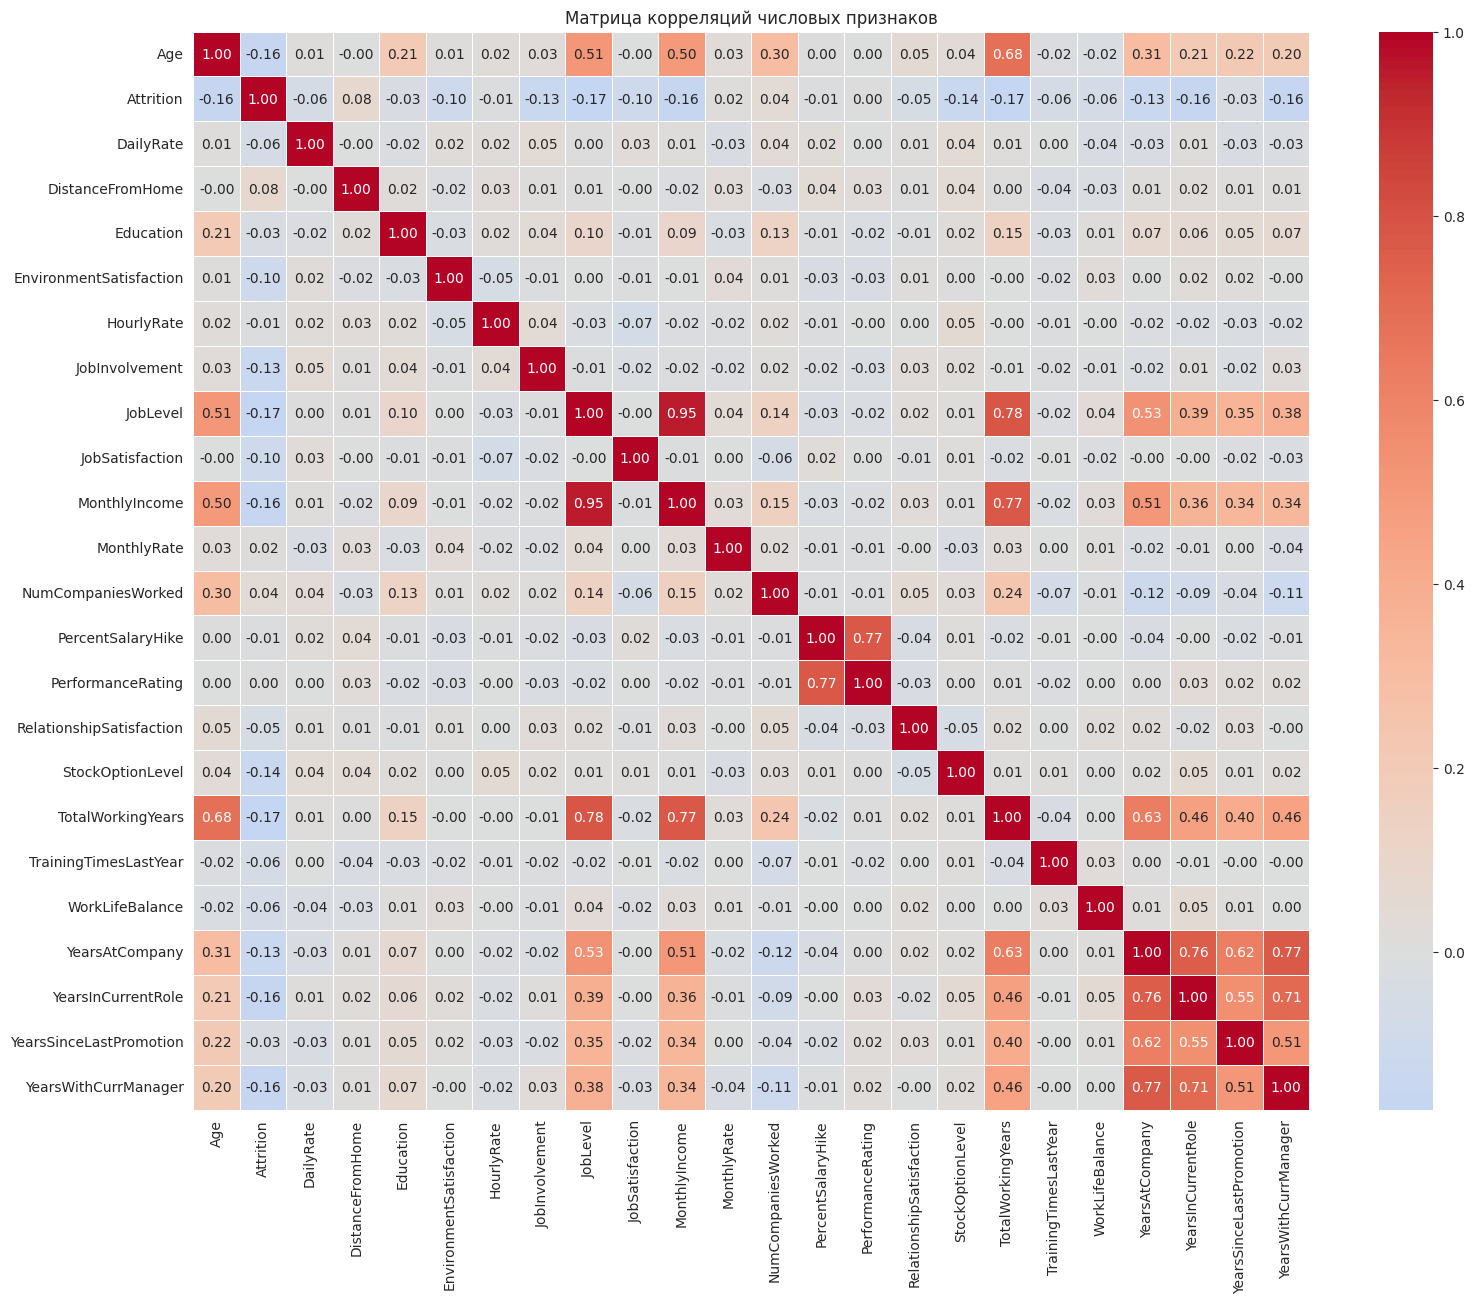

In [21]:
# Кодируем целевую переменную
df_corr = df.copy()
df_corr["Attrition"] = df_corr["Attrition"].map({"No": 0, "Yes": 1})

# Берем только числовые признаки
corr_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns

# Уберем служебные / неинформативные признаки
exclude_cols = ["EmployeeCount", "StandardHours", "EmployeeNumber"]
corr_cols = [col for col in corr_cols if col not in exclude_cols]

# Корреляционная матрица
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=False
)
plt.title("Матрица корреляций числовых признаков")
plt.show()

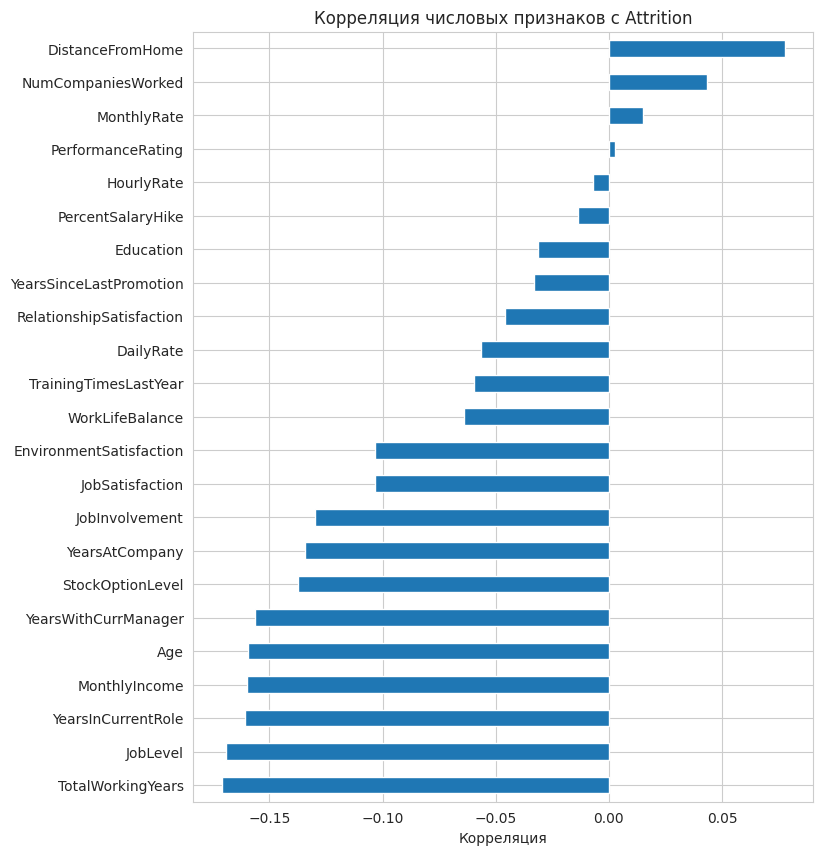

In [19]:
# Корреляция всех числовых признаков с Attrition
attrition_corr = corr_matrix["Attrition"].sort_values(ascending=False)
plt.figure(figsize=(8, 10))
attrition_corr.drop("Attrition").sort_values().plot(kind="barh")
plt.title("Корреляция числовых признаков с Attrition")
plt.xlabel("Корреляция")
plt.show()

**Анализ корреляций**

Для оценки взаимосвязей между числовыми признаками была построена корреляционная матрица. Она позволяет увидеть, какие переменные связаны между собой, а также какие признаки наиболее заметно связаны с целевой переменной `Attrition`.

По результатам анализа видно, что связи с `Attrition` в целом являются **слабыми**. Наиболее заметные по модулю отрицательные корреляции наблюдаются у признаков `TotalWorkingYears` (-0.171), `JobLevel` (-0.169), `YearsInCurrentRole` (-0.161), `MonthlyIncome` (-0.160), `Age` (-0.159) и `YearsWithCurrManager` (-0.156). Это означает, что с увеличением этих показателей вероятность увольнения в среднем снижается.

Положительная корреляция с `Attrition` выражена слабее всего: наиболее заметное значение наблюдается у `DistanceFromHome` (0.078), то есть с увеличением расстояния до работы вероятность увольнения может немного возрастать. Однако и здесь связь остаётся не очень сильной.

Также видно, что многие признаки, связанные со стажем и карьерным развитием, коррелируют друг с другом, что логично с точки зрения предметной области. В то же время невысокие значения корреляции с целевой переменной показывают, что увольнение сотрудника, скорее всего, определяется не одним фактором, а совокупностью нескольких признаков.

Таким образом, корреляционный анализ подтвердил, что задача предсказания attrition является многопризнаковой, и для построения качественной модели потребуется учитывать взаимодействие нескольких переменных.

# **6. Общий вывод по предварительному анализу данных**

В ходе разведочного анализа был изучен датасет IBM HR Analytics Employee Attrition & Performance, содержащий 1470 наблюдений и 35 признаков. Пропущенные значения в данных отсутствуют, поэтому набор можно использовать для дальнейшего анализа и построения модели без дополнительного заполнения пропусков.

Анализ целевой переменной показал, что классы несбалансированы: сотрудников, которые не уволились, значительно больше, чем уволившихся. Это важно учитывать при обучении модели и выборе метрик качества, поэтому наиболее подходящими будут recall, precision и F1-score.

При анализе числовых и категориальных признаков были выявлены основные особенности данных: распределения части признаков асимметричны, в наборе присутствуют отдельные выбросы, а также заметные различия между классами по ряду факторов, таких как стаж, доход, возраст, сверхурочная работа и частота командировок.

Корреляционный анализ показал, что связь между отдельными числовыми признаками и целевой переменной в целом слабая, поэтому для предсказания attrition важно учитывать не один, а совокупность факторов. В целом датасет подходит для решения задачи бинарной классификации и дальнейшего построения модели предсказания увольнения сотрудников.

В целом можно сделать вывод, что датасет является полным, хорошо структурированным и достаточно информативным для решения задачи бинарной классификации. Проведённый EDA позволил выявить основные особенности данных, подтвердить наличие дисбаланса классов, оценить распределения признаков и определить наиболее перспективные переменные для дальнейшего моделирования. Следующим этапом работы будет подготовка данных и построение модели, способной предсказывать вероятность увольнения сотрудников по имеющимся характеристикам.